# ML Workflow

  Dataset
    →
  Understand columns
    →
  Clean data
    →
  Handle missing values
    →
  EDA
    →
  Identify target column
    →
  Separate X and y
    →
  Encode categorical columns
    →
  Train/Test Split
    →
  Feature Scaling (if required)
    →
  Train ML model
    →
  Prediction
    →
  Evaluate model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rsrishav/tictactoe-endgame-data-set")

df=pd.read_table(os.path.join(path,'tic-tac-toe.data.csv'),sep=",")
df.head()

100%|██████████| 5.43k/5.43k [00:00<00:00, 9.28MB/s]

Extracting files...


,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square,Class
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   top-left-square       958 non-null    object
 1   top-middle-square     958 non-null    object
 2   top-right-square      958 non-null    object
 3   middle-left-square    958 non-null    object
 4   middle-middle-square  958 non-null    object
 5   middle-right-square   958 non-null    object
 6   bottom-left-square    958 non-null    object
 7   bottom-middle-square  958 non-null    object
 8   bottom-right-square   958 non-null    object
 9   Class                 958 non-null    object
dtypes: object(10)
memory usage: 75.0+ KB


In [4]:
df.describe()

,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square,Class
count,958,958,958,958,958,958,958,958,958,958
unique,3,3,3,3,3,3,3,3,3,2
top,x,x,x,x,x,x,x,x,x,positive
freq,418,378,418,378,458,378,418,378,418,626


In [5]:
df.isnull().sum()

,0
top-left-square,0
top-middle-square,0
top-right-square,0
middle-left-square,0
middle-middle-square,0
middle-right-square,0
bottom-left-square,0
bottom-middle-square,0
bottom-right-square,0
Class,0


In [6]:
cat_cols = df.select_dtypes(include='object').columns
print("\nCategorical:")
print(cat_cols)


Categorical:
Index(['top-left-square', 'top-middle-square', 'top-right-square',
       'middle-left-square', 'middle-middle-square', 'middle-right-square',
       'bottom-left-square', 'bottom-middle-square', 'bottom-right-square',
       'Class'],
      dtype='object')


In [7]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[cat_cols] = oe.fit_transform(df[cat_cols])

In [8]:
df

,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square,Class
0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0
1,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0
2,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0
3,2.0,2.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0
4,2.0,2.0,2.0,2.0,1.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
953,1.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,0.0
954,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,0.0
955,1.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,0.0
956,1.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,0.0


In [9]:
df.describe()

,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square,Class
count,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000
mean,1.222338,1.133612,1.222338,1.133612,1.311065,1.133612,1.222338,1.133612,1.222338,0.653445
std,0.775569,0.798966,0.775569,0.798966,0.740882,0.798966,0.775569,0.798966,0.775569,0.476121
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000


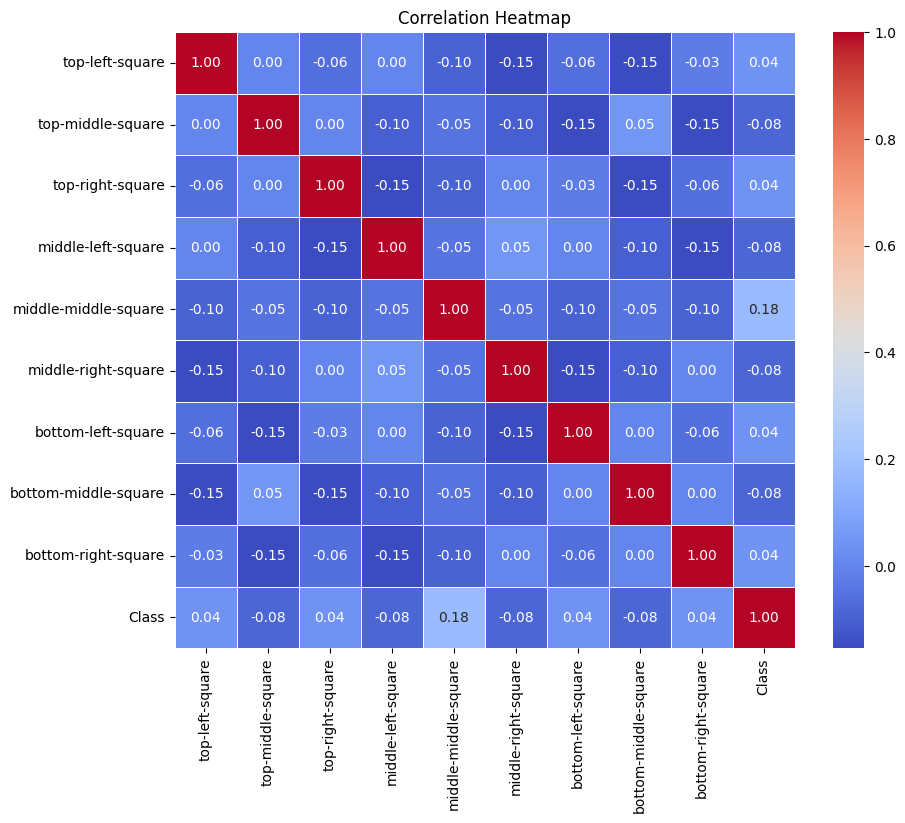

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

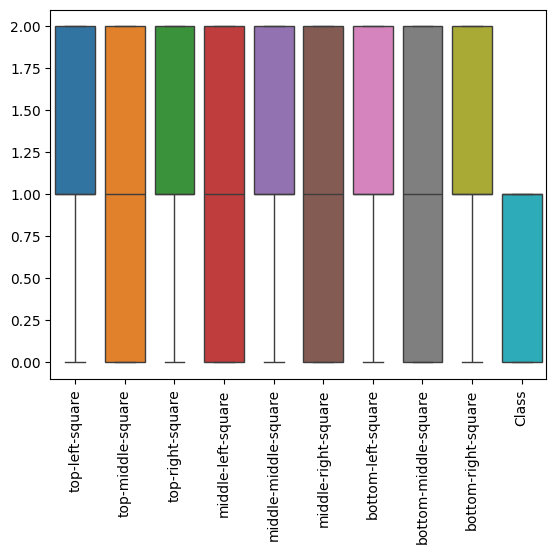

In [11]:
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

Column: top-left-square
Skewness: -0.406733014291662


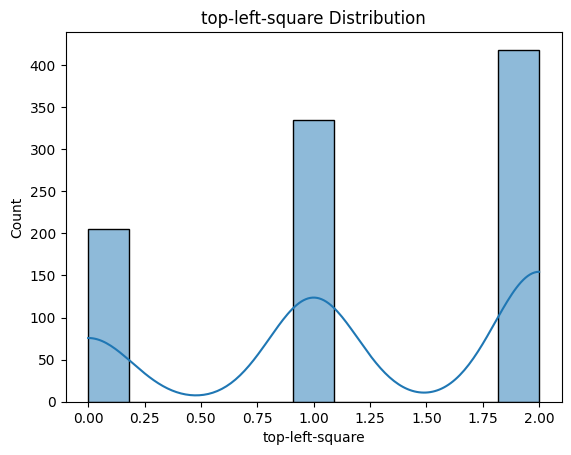

Column: top-middle-square
Skewness: -0.2442528880886251


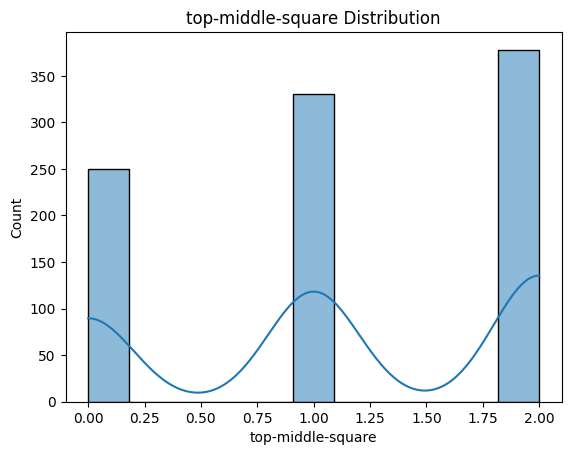

Column: top-right-square
Skewness: -0.4067330142916621


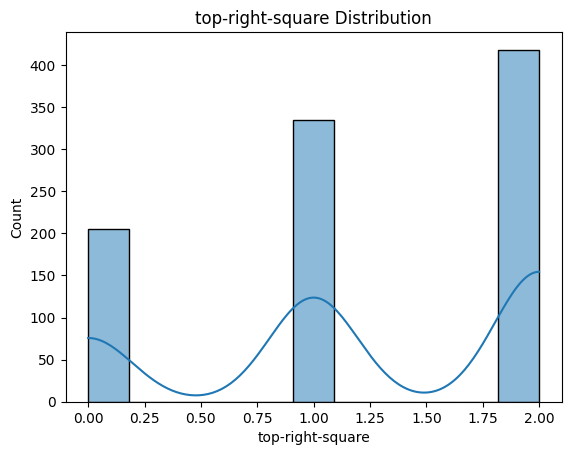

Column: middle-left-square
Skewness: -0.24425288808862516


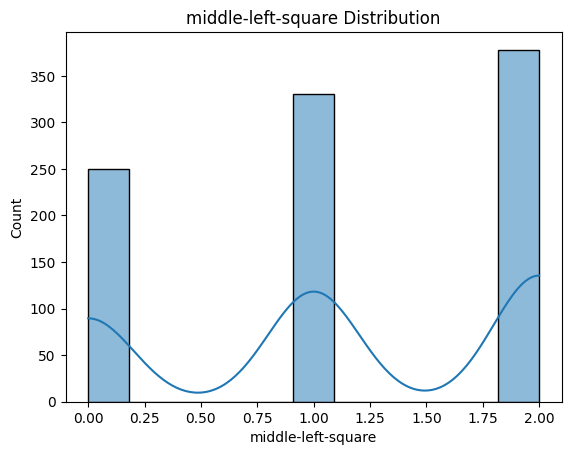

Column: middle-middle-square
Skewness: -0.5682606230590672


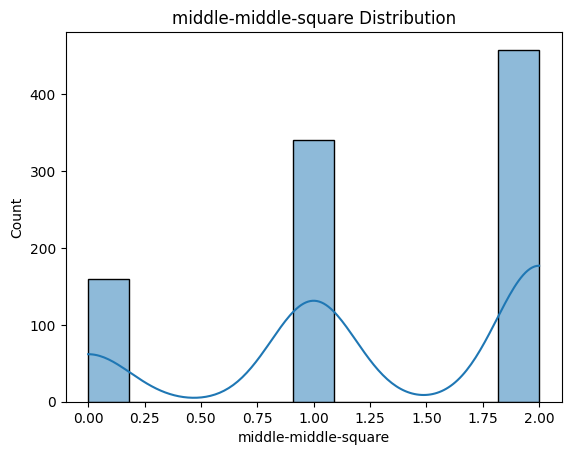

Column: middle-right-square
Skewness: -0.24425288808862516


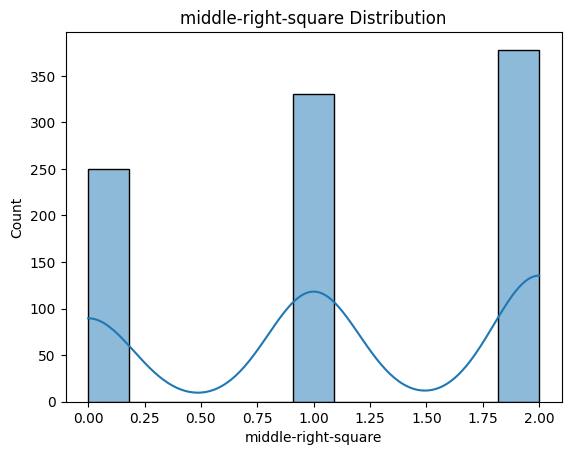

Column: bottom-left-square
Skewness: -0.4067330142916621


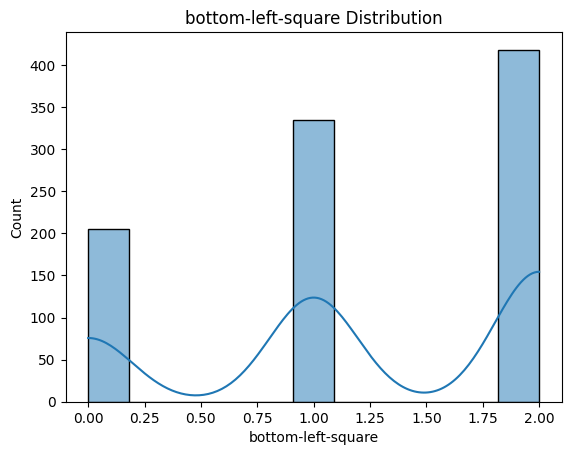

Column: bottom-middle-square
Skewness: -0.24425288808862516


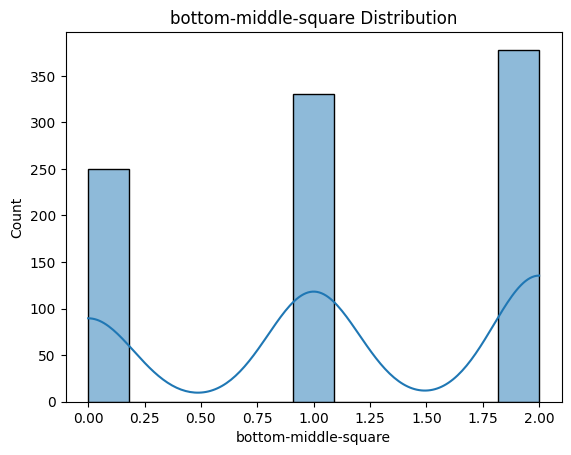

Column: bottom-right-square
Skewness: -0.4067330142916622


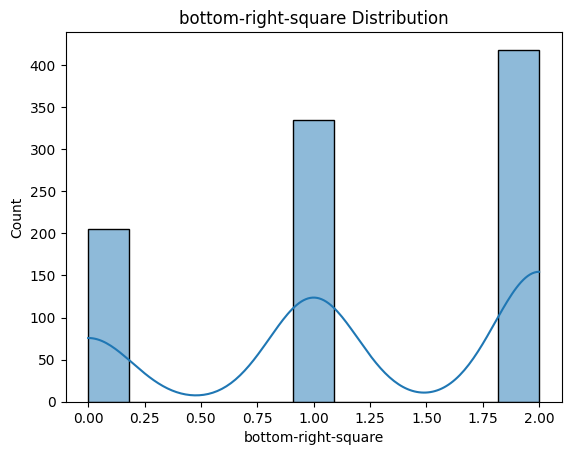

Column: Class
Skewness: -0.6448981364327077


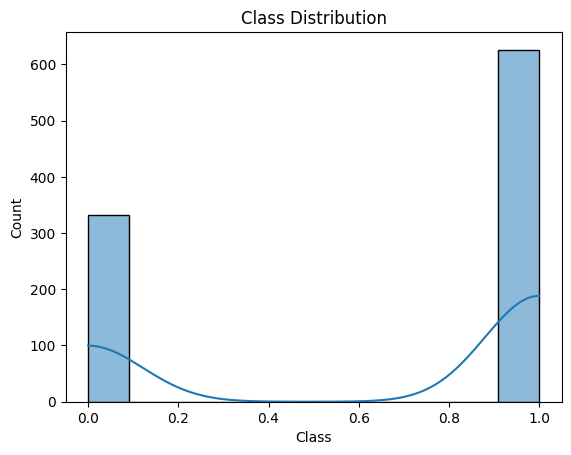

In [12]:
from scipy.stats import skew
colname = df.select_dtypes(include='number').columns
for col in colname:
    print("Column:", col)
    print("Skewness:", skew(df[col].dropna()))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [13]:
X=df.drop('Class',axis=1)
Y=df['Class']

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [16]:
models = []
r2_scores = []
accuracy_scores = []

In [17]:
def mynewmodel():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    from sklearn.metrics import r2_score
    from sklearn.metrics import accuracy_score

    models.append(('Logistic Regression', LogisticRegression()))
    models.append(('Decision Tree Classifier', DecisionTreeClassifier()))
    models.append(('Random Forest Classifier', RandomForestClassifier()))
    models.append(('SVC', SVC()))
    models.append(('KNeighbors Classifier', KNeighborsClassifier()))

    for name, model in models:
        model.fit(X_train, Y_train)
        predictions = model.predict(X_test)
        r2 = r2_score(Y_test, predictions)
        accuracy = accuracy_score(Y_test, predictions)
        print(f"Name of Model: {name}")
        print(f"  R-squared: {r2}")
        print(f"  Accuracy: {accuracy}")
        train = model.score(X_train, Y_train)
        test = model.score(X_test, Y_test)
        print(f"  Training score: {train}")
        print(f"  Testing score: {test}")
        print("")
        r2_scores.append(r2)
        accuracy_scores.append(accuracy)

    arr=np.array(r2_scores)
    print(f"Average R-squared score: {arr.mean()}")
    arr=np.array(accuracy_scores)
    print(f"Average Accuracy score: {arr.mean()}")

In [18]:
mynewmodel()

Name of Model: Logistic Regression
  R-squared: -0.3846153846153846
  Accuracy: 0.6805555555555556
  Training score: 0.6835820895522388
  Testing score: 0.6805555555555556

Name of Model: Decision Tree Classifier
  R-squared: 0.21739130434782605
  Accuracy: 0.8194444444444444
  Training score: 1.0
  Testing score: 0.8194444444444444

Name of Model: Random Forest Classifier
  R-squared: 0.774247491638796
  Accuracy: 0.9479166666666666
  Training score: 1.0
  Testing score: 0.9479166666666666

Name of Model: SVC
  R-squared: 0.382943143812709
  Accuracy: 0.8576388888888888
  Training score: 0.9149253731343283
  Testing score: 0.8576388888888888

Name of Model: KNeighbors Classifier
  R-squared: 0.24749163879598657
  Accuracy: 0.8263888888888888
  Training score: 0.844776119402985
  Testing score: 0.8263888888888888

Average R-squared score: 0.24749163879598662
Average Accuracy score: 0.826388888888889


In [19]:
RFC = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=2, random_state=42)
RFC.fit(X_train, Y_train)
train = RFC.score(X_train, Y_train)
test = RFC.score(X_test, Y_test)
print(f"Training score: {train}")
print(f"Testing score: {test}")

Training score: 0.9641791044776119
Testing score: 0.8784722222222222


In [20]:
DT = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
DT.fit(X_train, Y_train)
train = DT.score(X_train, Y_train)
test = DT.score(X_test, Y_test)
print(f"Training score: {train}")
print(f"Testing score: {test}")

Training score: 0.8253731343283582
Testing score: 0.7951388888888888
